# NASA Turbofan — Exploratory Data Analysis

Dataset: CMAPSS (Commercial Modular Aero-Propulsion System Simulation)  
4 sub-datasets: FD001–FD004, each with different operating conditions and fault modes.

| Dataset | Train units | Test units | Conditions | Fault modes |
|---------|------------|-----------|------------|-------------|
| FD001   | 100        | 100       | 1          | 1           |
| FD002   | 260        | 259       | 6          | 1           |
| FD003   | 100        | 100       | 1          | 2           |
| FD004   | 248        | 248       | 6          | 2           |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sns.set_theme(style='darkgrid', palette='muted')
pd.set_option('display.max_columns', 30)

DATA_DIR = Path('../data/CMaps')

## 1. Load Data

In [2]:
INDEX_COLS  = ['unit', 'cycle']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS  = [f's_{i}' for i in range(1, 22)]
ALL_COLS     = INDEX_COLS + SETTING_COLS + SENSOR_COLS

def load_dataset(fd_id: int):
    """Load train, test, and RUL ground-truth for a given FD sub-dataset."""
    train = pd.read_csv(DATA_DIR / f'train_FD00{fd_id}.txt',
                        sep=r'\s+', header=None, names=ALL_COLS, index_col=False)
    test  = pd.read_csv(DATA_DIR / f'test_FD00{fd_id}.txt',
                        sep=r'\s+', header=None, names=ALL_COLS, index_col=False)
    rul   = pd.read_csv(DATA_DIR / f'RUL_FD00{fd_id}.txt',
                        sep=r'\s+', header=None, names=['RUL'], index_col=False)

    # Compute RUL for training data
    max_cycle = train.groupby('unit')['cycle'].max().rename('max_cycle')
    train = train.merge(max_cycle, on='unit')
    train['RUL'] = train['max_cycle'] - train['cycle']
    train.drop(columns='max_cycle', inplace=True)

    # Assign ground-truth RUL to the last observed cycle of each test unit
    last_test = test.groupby('unit', as_index=False).last()
    last_test['RUL'] = rul['RUL'].values

    return train, test, last_test, rul


datasets = {fd: load_dataset(fd) for fd in range(1, 5)}
train1, test1, last_test1, rul1 = datasets[1]

print('FD001 train shape:', train1.shape)
print('FD001 test shape :', test1.shape)
train1.head()

FD001 train shape: (20631, 27)
FD001 test shape : (13096, 26)


,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## 2. Basic Statistics

In [3]:
print('=== FD001 Train — descriptive stats ===')
train1[SENSOR_COLS + ['RUL']].describe().T.round(3)

=== FD001 Train — descriptive stats ===


,count,mean,std,min,25%,50%,75%,max
s_1,20631.0,518.670,0.000,518.670,518.670,518.670,518.670,518.670
s_2,20631.0,642.681,0.500,641.210,642.325,642.640,643.000,644.530
s_3,20631.0,1590.523,6.131,1571.040,1586.260,1590.100,1594.380,1616.910
s_4,20631.0,1408.934,9.001,1382.250,1402.360,1408.040,1414.555,1441.490
s_5,20631.0,14.620,0.000,14.620,14.620,14.620,14.620,14.620
s_6,20631.0,21.610,0.001,21.600,21.610,21.610,21.610,21.610
s_7,20631.0,553.368,0.885,549.850,552.810,553.440,554.010,556.060
s_8,20631.0,2388.097,0.071,2387.900,2388.050,2388.090,2388.140,2388.560
s_9,20631.0,9065.243,22.083,9021.730,9053.100,9060.660,9069.420,9244.590
s_10,20631.0,1.300,0.000,1.300,1.300,1.300,1.300,1.300


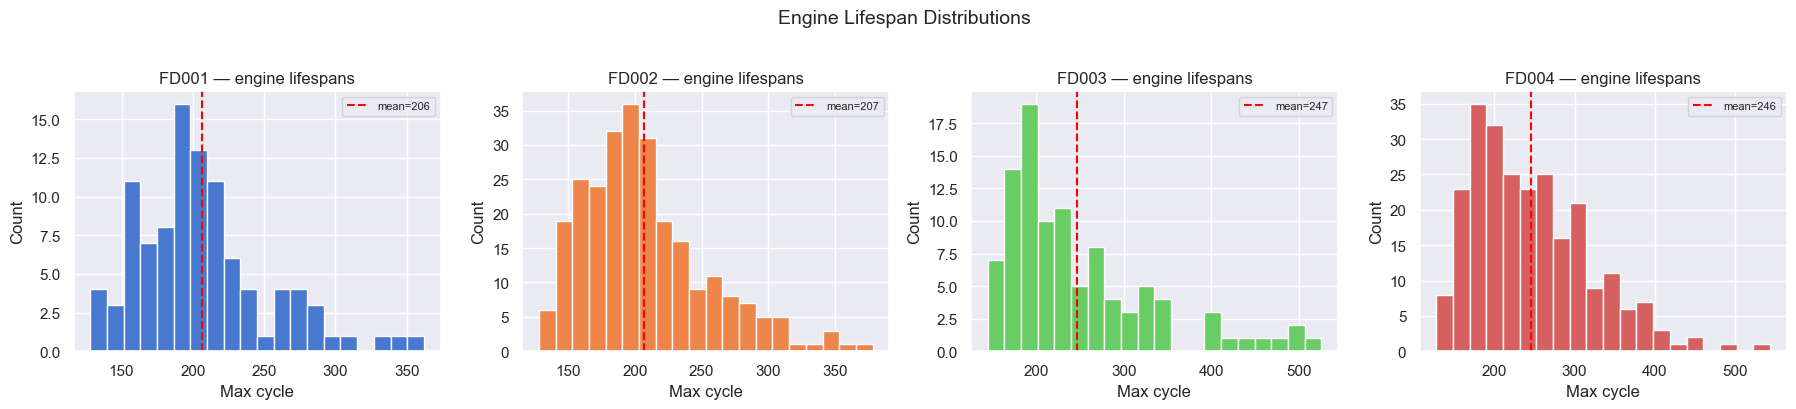

In [4]:
# Life-span distribution across all 4 datasets
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
for fd, ax in zip(range(1, 5), axes):
    train, *_ = datasets[fd]
    lifespans = train.groupby('unit')['cycle'].max()
    ax.hist(lifespans, bins=20, edgecolor='white', color=sns.color_palette()[fd-1])
    ax.set_title(f'FD00{fd} — engine lifespans')
    ax.set_xlabel('Max cycle')
    ax.set_ylabel('Count')
    ax.axvline(lifespans.mean(), color='red', linestyle='--', label=f'mean={lifespans.mean():.0f}')
    ax.legend(fontsize=8)
plt.suptitle('Engine Lifespan Distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 3. Sensor Variance & Constant-Feature Detection

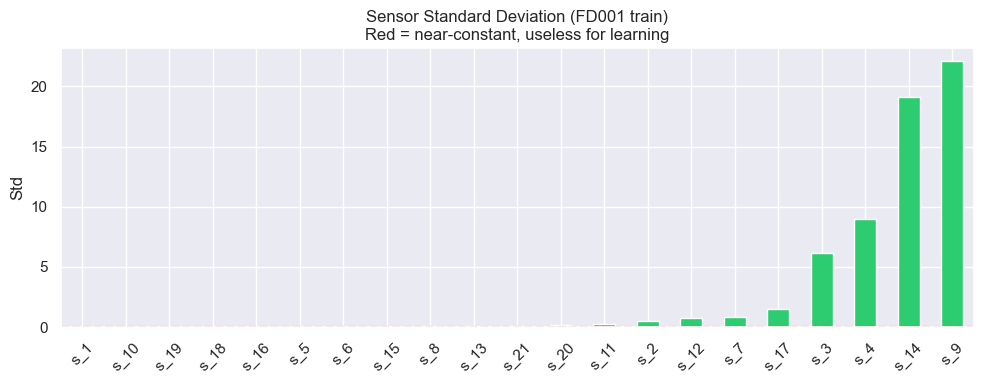

Constant / near-constant sensors (will be dropped): ['s_1', 's_10', 's_19', 's_18', 's_16', 's_5']
Useful sensors: ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


In [5]:
sensor_std = train1[SENSOR_COLS].std().sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v < 1e-3 else '#2ecc71' for v in sensor_std]
sensor_std.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Sensor Standard Deviation (FD001 train)\nRed = near-constant, useless for learning')
ax.set_ylabel('Std')
ax.axhline(1e-3, color='red', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

DEAD_SENSORS = sensor_std[sensor_std < 1e-3].index.tolist()
LIVE_SENSORS = [s for s in SENSOR_COLS if s not in DEAD_SENSORS]
print('Constant / near-constant sensors (will be dropped):', DEAD_SENSORS)
print('Useful sensors:', LIVE_SENSORS)

## 4. Sensor–RUL Correlation

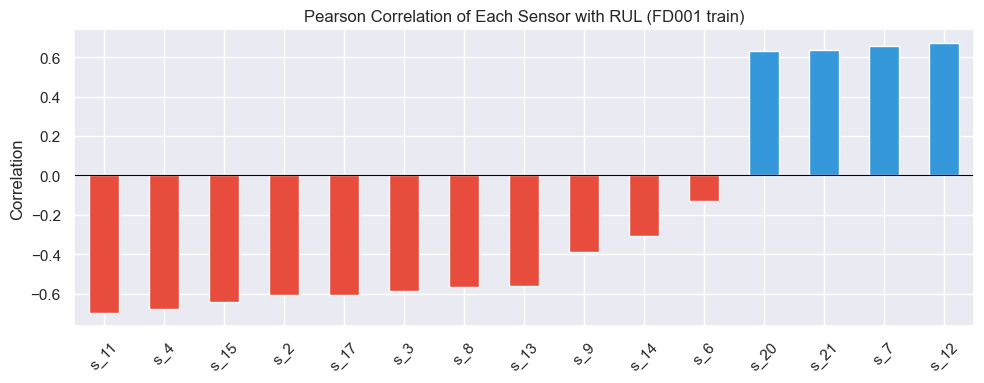

In [6]:
corr_with_rul = train1[LIVE_SENSORS + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v < 0 else '#3498db' for v in corr_with_rul]
corr_with_rul.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Pearson Correlation of Each Sensor with RUL (FD001 train)')
ax.set_ylabel('Correlation')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig('../assets/sensor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


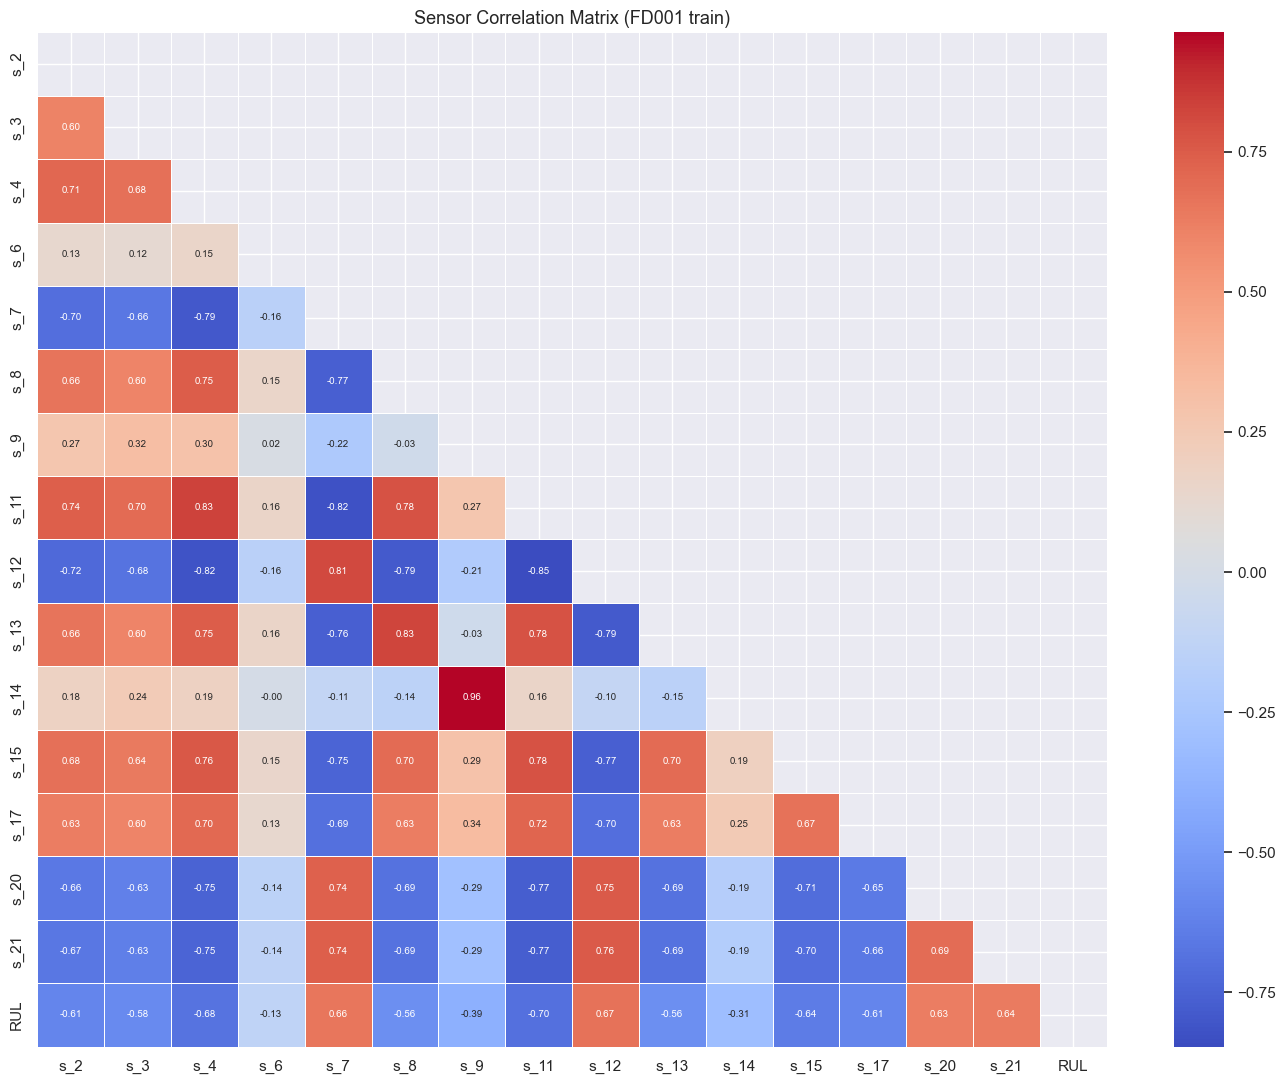

In [7]:
# Full correlation heatmap
fig, ax = plt.subplots(figsize=(14, 11))
corr_mat = train1[LIVE_SENSORS + ['RUL']].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', ax=ax,
            cmap='coolwarm', linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Sensor Correlation Matrix (FD001 train)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Sensor Degradation Trajectories

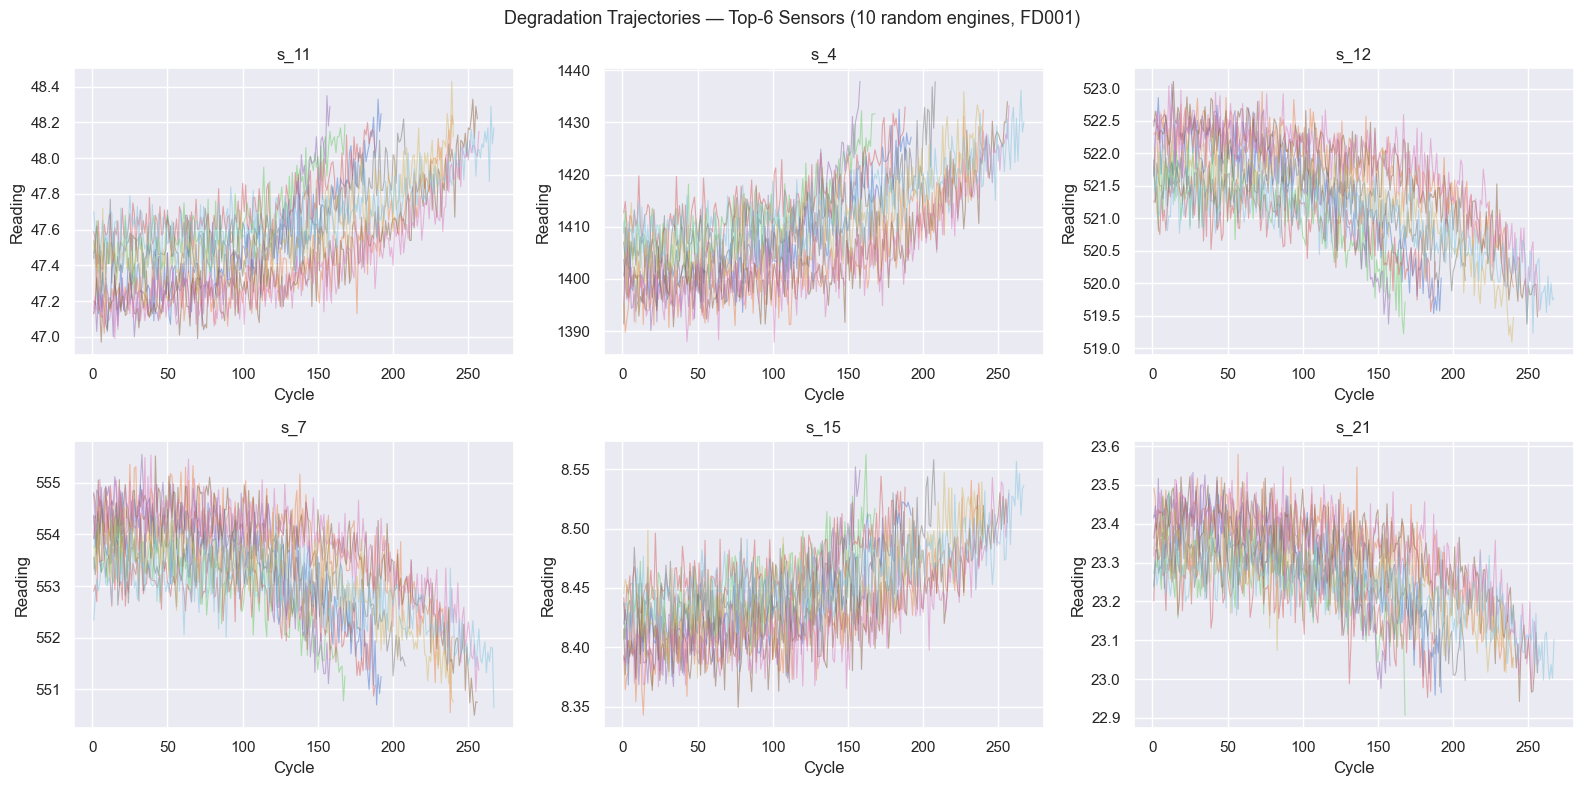

In [8]:
# Pick the 6 sensors most correlated with RUL (by absolute value)
top6 = corr_with_rul.abs().nlargest(6).index.tolist()

# Sample 10 random engines for plotting
np.random.seed(42)
sample_units = np.random.choice(train1['unit'].unique(), 10, replace=False)
subset = train1[train1['unit'].isin(sample_units)]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, sensor in zip(axes.flat, top6):
    for uid, grp in subset.groupby('unit'):
        ax.plot(grp['cycle'], grp[sensor], alpha=0.5, linewidth=0.8)
    ax.set_title(sensor)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Reading')
plt.suptitle('Degradation Trajectories — Top-6 Sensors (10 random engines, FD001)', fontsize=13)
plt.tight_layout()
fig.savefig('../assets/degradation_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. RUL Distribution & Piecewise-Linear Cap

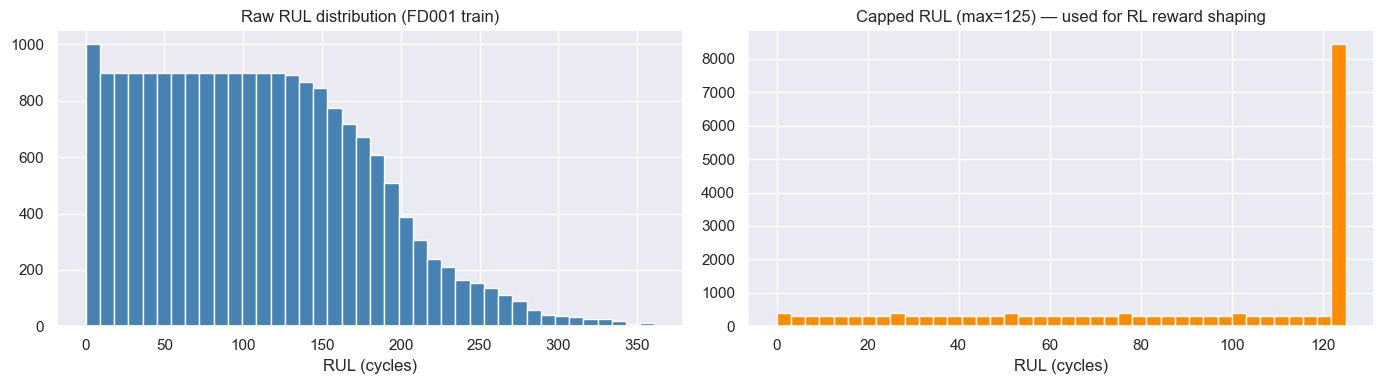

In [9]:
RUL_CAP = 125  # common choice for CMAPSS; engines rarely degrade in a detectable
               # way until within ~125 cycles of failure

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train1['RUL'], bins=40, edgecolor='white', color='steelblue')
axes[0].set_title('Raw RUL distribution (FD001 train)')
axes[0].set_xlabel('RUL (cycles)')

capped = train1['RUL'].clip(upper=RUL_CAP)
axes[1].hist(capped, bins=40, edgecolor='white', color='darkorange')
axes[1].set_title(f'Capped RUL (max={RUL_CAP}) — used for RL reward shaping')
axes[1].set_xlabel('RUL (cycles)')

plt.tight_layout()
plt.show()

## 7. Operating Condition Clusters (FD002 / FD004)

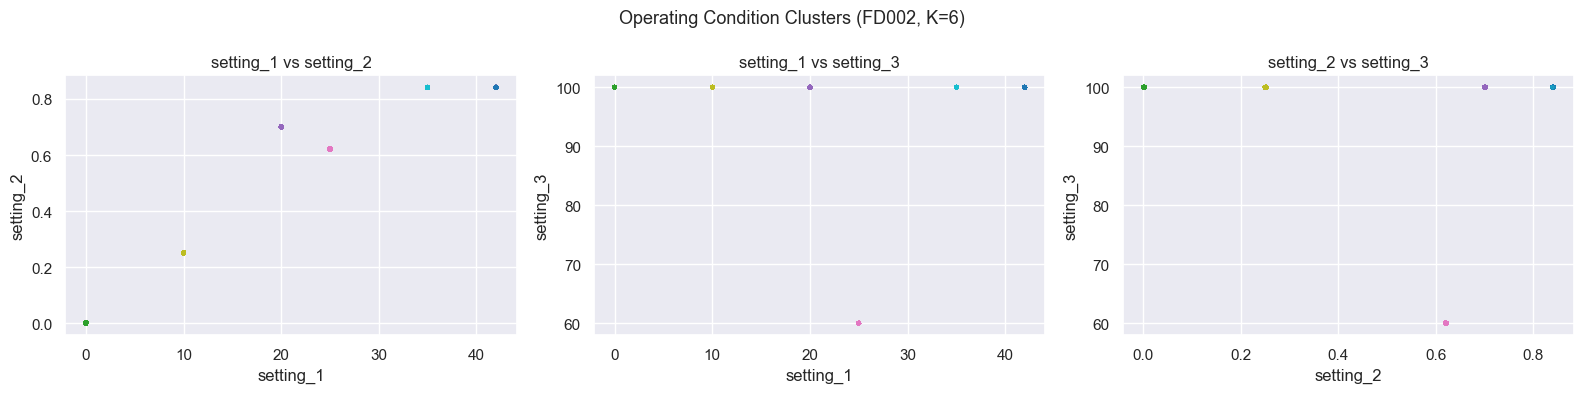

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

train2, *_ = datasets[2]
settings = train2[SETTING_COLS].values
settings_scaled = StandardScaler().fit_transform(settings)

km = KMeans(n_clusters=6, random_state=42, n_init=10)
train2['op_condition'] = km.fit_predict(settings_scaled)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pairs = [('setting_1', 'setting_2'), ('setting_1', 'setting_3'), ('setting_2', 'setting_3')]
for ax, (x, y) in zip(axes, pairs):
    scatter = ax.scatter(train2[x], train2[y], c=train2['op_condition'],
                         cmap='tab10', alpha=0.3, s=5)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
plt.suptitle('Operating Condition Clusters (FD002, K=6)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Rolling-Window Feature Preview

For the RL state representation we will use a **rolling window of `W` cycles**.  
Here we visualise how a window-averaged signal compares to the raw sensor.

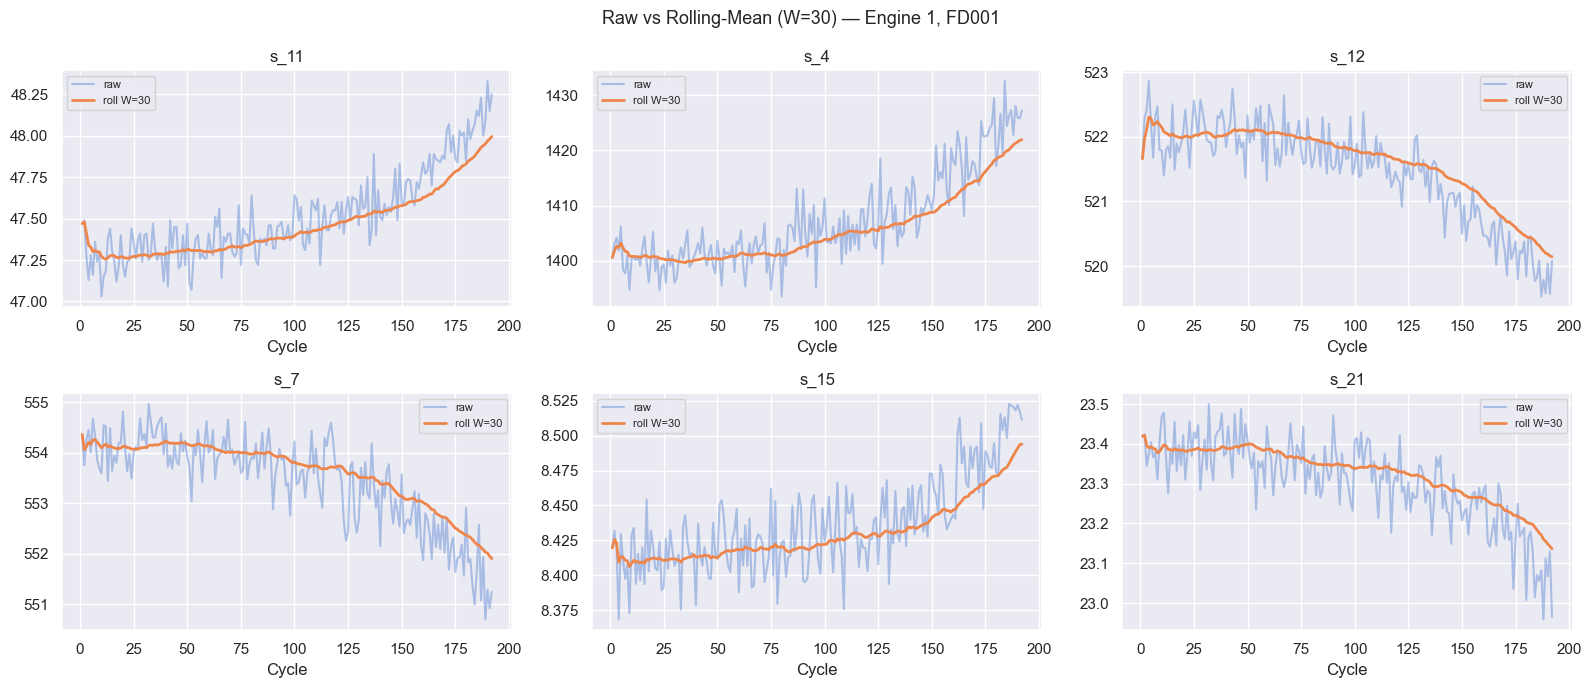

In [11]:
W = 30  # window size used in the RL notebooks

engine_1 = train1[train1['unit'] == 1].copy()
for s in LIVE_SENSORS:
    engine_1[f'{s}_roll'] = engine_1[s].rolling(W, min_periods=1).mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, sensor in zip(axes.flat, top6):
    ax.plot(engine_1['cycle'], engine_1[sensor], alpha=0.4, label='raw')
    ax.plot(engine_1['cycle'], engine_1[f'{sensor}_roll'], linewidth=2, label=f'roll W={W}')
    ax.set_title(sensor)
    ax.set_xlabel('Cycle')
    ax.legend(fontsize=8)
plt.suptitle(f'Raw vs Rolling-Mean (W={W}) — Engine 1, FD001', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Summary — Features Selected for RL Experiments

In [12]:
print('Dead sensors (dropped)     :', DEAD_SENSORS)
print('Live sensors               :', LIVE_SENSORS)
print('Top-6 by |corr with RUL|   :', top6)
print('RUL cap                    :', RUL_CAP)
print('Rolling window W           :', W)
print('State dim (live sensors)   :', len(LIVE_SENSORS))
print()
print('These constants are re-used in 02_q_learning.ipynb and 03_deep_q_learning.ipynb')

Dead sensors (dropped)     : ['s_1', 's_10', 's_19', 's_18', 's_16', 's_5']
Live sensors               : ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
Top-6 by |corr with RUL|   : ['s_11', 's_4', 's_12', 's_7', 's_15', 's_21']
RUL cap                    : 125
Rolling window W           : 30
State dim (live sensors)   : 15

These constants are re-used in 02_q_learning.ipynb and 03_deep_q_learning.ipynb
